In [1]:
%matplotlib inline
import random
import torch
import matplotlib.pyplot as plt

In [3]:
def synthetic_data(w,b,num_examples):
  X=torch.normal(0,1,(num_examples,len(w)))
  y=torch.matmul(X,w)+b
  y+=torch.normal(0,0.01,y.shape)
  return X,y.reshape((-1,1))

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)
print('features:',features[0],'\nlabel:',labels[0])

features: tensor([0.6618, 0.0309]) 
label: tensor([5.4167])


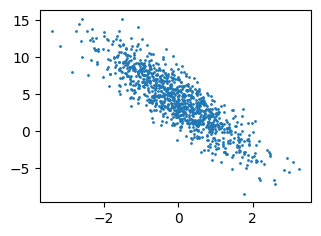

In [7]:
plt.figure(figsize=(3.5,2.5))
plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),s=1)
plt.show()


In [9]:
def data_iter(batch_size,features,labels):
  num_examples = len(features)
  indices = list(range(num_examples))
  random.shuffle(indices)
  for i in range(0,num_examples,batch_size):
    batch_indices = torch.tensor(indices[i:min(i+batch_size,num_examples)])
    yield features[batch_indices],labels[batch_indices]

In [10]:
batch_size=10
for X,y in data_iter(batch_size,features,labels):
  print(X,"\n",y)
  break


tensor([[-0.7257, -0.1126],
        [ 1.0765, -2.5985],
        [ 0.6522,  2.4361],
        [-0.3048,  0.1658],
        [-1.1638,  0.2826],
        [ 0.4936,  1.3631],
        [ 0.3747,  0.7203],
        [-0.1687,  0.1680],
        [ 2.4732, -0.9760],
        [-0.6042,  1.7768]]) 
 tensor([[ 3.1420],
        [15.1959],
        [-2.7610],
        [ 3.0320],
        [ 0.9320],
        [ 0.5540],
        [ 2.4925],
        [ 3.2998],
        [12.4844],
        [-3.0520]])


In [11]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

In [13]:
def linreg(X,w,b):
  return torch.matmul(X,w)+b

In [14]:
def squared_loss(y_hat,y):
  return (y_hat-y.reshape(y_hat.shape))**2 / 2

In [15]:
def sgd(params, lr, batch_size):
  with torch.no_grad():
    for param in params:
      param -= lr * param.grad / batch_size
      param.grad.zero_()

In [17]:
lr=0.03
num_epoch=3
net=linreg
loss=squared_loss
for epoch in range(num_epoch):
  for X,y in data_iter(batch_size,features,labels):
    l=loss(net(X,w,b),y)
    l.sum().backward()
    sgd([w,b],lr,batch_size)
  with torch.no_grad():
    train_l=loss(net(features,w,b),labels)
    print(f'epoch {epoch+1}, loss {float(train_l.sum()):f}')

epoch 1, loss 0.048459
epoch 2, loss 0.048295
epoch 3, loss 0.048396


In [18]:
print(f"w的误差:{true_w-w.reshape(true_w.shape)}")
print(f"b的误差:{true_b-b}")

w的误差:tensor([-0.0003,  0.0003], grad_fn=<SubBackward0>)
b的误差:tensor([-0.0007], grad_fn=<RsubBackward1>)
